# Análisis de sarcasmo 

## Objetivo del proyecto
Desarrollar un sistema capaz de identificar automáticamente si un comentario contiene sarcasmo o no, utilizando técnicas de procesamiento de lenguaje natural y modelos de aprendizaje automático.

## Equipo: Los Trastornados
- González Hernández Diego  
- Junco Martínez Bruno Salvador  
- Miranda Ferreyra Uriel  
- Santiago Illoldi Francisco Javier  
- Valdez García Paola Sarai  

In [36]:
# CELDA 0: Intalación de dependencias
# Esta celda se usa SOLO si no tienes instaladas

!pip install --upgrade pandas numpy scikit-learn nltk streamlit datasets emoji transformers torch matplotlib seaborn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\pv030\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [37]:
# CELDA 1: Importación de librerías

import emoji

# Manejo de datos
import pandas as pd
import numpy as np

#  Procesamiento de texto
import re                      # Expresiones regulares (limpieza de texto)
import unicodedata            # Normalización de acentos
import nltk
from nltk.corpus import stopwords

# Descargar recursos necesarios de NLTK (solo la primera vez)
nltk.download('stopwords')

# División de datos

from sklearn.model_selection import train_test_split

#  Vectorización de texto
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Modelos de Machine Learning
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

#  Evaluación del modelo
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Transformer HuggingFace
from transformers import pipeline

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pv030\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [38]:
# CELDA 2: Cargar dataset desde Hugging Face
from datasets import load_dataset
import pandas as pd

# Descargamos un corpus de sarcasmo 100% en español directamente preparado
print("Descargando el dataset desde Hugging Face...")
dataset = load_dataset('Ernesto-1997/Sarcastic_spanish_dataset')

# Convertimos el bloque de entrenamiento a DataFrame de pandas
df = dataset['train'].to_pandas()

# Aseguramos que las columnas tengan los mismos nombres que esperaba tu código original
df.rename(columns={'Texto': 'comentario', 'Sarcasmo': 'sarcasmo'}, inplace=True)

# Mostramos las primeras filas para comprobar que se cargó bien con texto en español
df.head()


Descargando el dataset desde Hugging Face...


,comentario,sarcasmo
0,Así son las grabaciones que comprometen a Fern...,1
1,Clan TV no sabe cómo preparar a los niños para...,1
2,Muelas de elefante y casuarios: así aprenden e...,0
3,"Qué bien, las discusiones solo fortalecen la r...",1
4,Clásicos en Alcalá dedica este año a Cervantes...,0


In [39]:
# CELDA 3: Preprocesamiento exhaustivo preservando emojis 

stop_words = set(stopwords.words('spanish'))

def limpiar_texto(texto):
    if not isinstance(texto, str):
        return ""
        
    # 1. Convertir a minúsculas
    texto = texto.lower()
    
    # 2. Eliminar URLs, menciones, y hashtags inservibles (opcional mantener el texto del hashtag)
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto)
    texto = re.sub(r'@\w+', '', texto)
    texto = re.sub(r'#', '', texto) # Quitamos solo el símbolo de gato, dejamos la palabra
    
    # 3. Extraer emojis usando la librería 'emoji' ANTES de quitarlos con regex
    # Obtenemos todos los emojis para volver a pegarlos al final
    emojis_en_texto = [c['emoji'] for c in emoji.emoji_list(texto)]
    
    # 4. Quitar acentos SIN romper la codificación (NO usar ascii encode)
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    
    # 5. Eliminar puntuación y caracteres especiales (incluyendo los emojis que ya salvamos)
    texto = re.sub(r'[^\w\s]', ' ', texto)
    
    # 6. Eliminar números (opcional, pero útil para sarcasmo)
    texto = re.sub(r'\b\d+\b', '', texto)
    
    # 7. Tokenizar y limpiar stopwords
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words]
    
    # 8. Reconstruir texto
    texto_limpio = " ".join(palabras)
    
    # 9. Añadir emojis rescatados (son MUY importantes para detectar sarcasmo)
    if emojis_en_texto:
        texto_limpio += " " + " ".join(emojis_en_texto)
        
    # 10. Eliminar espacios dobles
    texto_limpio = re.sub(r'\s+', ' ', texto_limpio).strip()
    
    return texto_limpio

# Aplicar limpieza exhaustiva (puede tardar un poco)
df["comentario_limpio"] = df["comentario"].apply(limpiar_texto)

# Mostrar el antes y el después para verificar
df[['comentario', 'comentario_limpio']].head(10)

,comentario,comentario_limpio
0,Así son las grabaciones que comprometen a Fern...,asi grabaciones comprometen fernandez diaz
1,Clan TV no sabe cómo preparar a los niños para...,clan tv sabe preparar ninos matanza peppa pig
2,Muelas de elefante y casuarios: así aprenden e...,muelas elefante casuarios asi aprenden ecologi...
3,"Qué bien, las discusiones solo fortalecen la r...",bien discusiones solo fortalecen relacion verdad
4,Clásicos en Alcalá dedica este año a Cervantes...,clasicos alcala dedica ano cervantes parte pro...
5,Jálame el dedo.,jalame dedo
6,El baño gastronómico del agua termal,bano gastronomico agua termal
7,El regreso a la escena pública de Kate Middlet...,regreso escena publica kate middleton acapara ...
8,Comparativa: Ir a Granada en tren vs. Volver a...,comparativa ir granada tren vs volver madrid f...
9,El Gobierno cobrará una tasa a los que se leva...,gobierno cobrara tasa levanten energia


In [40]:
# CELDA 4: División de los datos 
# Aquí separamos los datos en:
# - Entrenamiento (para enseñar al modelo)
# - Prueba (para evaluar qué tan bien funciona)

# MUY IMPORTANTE: A veces la limpieza deja textos vacíos (ej. si un comentario solo era un link).
# Filtramos para asegurarnos de quitar los que quedaron completamente vacíos.
df = df[df["comentario_limpio"].str.strip() != ""]

# Variables de entrada (X) y salida (y)
X = df["comentario_limpio"]
y = df["sarcasmo"]

# División (70% entrenamiento, 30% prueba)
# Agregamos 'stratify=y' para garantizar que mantenga el mismo porcentaje de sarcasmo en ambas particiones.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"Total Entrenamiento: {len(X_train)} comentarios")
print(f"Total Prueba: {len(X_test)} comentarios")

Total Entrenamiento: 10679 comentarios
Total Prueba: 4577 comentarios


In [41]:
# CELDA 5: Vectorización (Bag of Words)
# Utilizamos Bag of Words (CountVectorizer) que cuenta la frecuencia de cada palabra o frase clave.

# Creamos el Vectorizador de Bag of Words
# max_features limita a las 8000 palabras más representativas para no saturar los modelos.
vectorizer = CountVectorizer(max_features=8000)

# Ajustamos el modelo (aprende el diccionario) y transformamos los datos de entrenamiento
X_train_vec = vectorizer.fit_transform(X_train)

# Transformamos los datos de prueba (usando SOLO el vocabulario aprendido en el entrenamiento)
X_test_vec = vectorizer.transform(X_test)

print(f"Vocabulario temporal del Bag of Words: {X_train_vec.shape[1]} tokens listos.")

Vocabulario temporal del Bag of Words: 8000 tokens listos.


In [54]:
# CELDA 6: Función para evaluar modelos 
# Mejorada para graficar matplotlib / seaborn
import matplotlib.pyplot as plt
import seaborn as sns

def evaluar_modelo(nombre, y_test, y_pred):
    print(f"\n{'='*20} {nombre} {'='*20}")
    
    # Accuracy (qué tan correcto es en porcentaje global)
    acc = accuracy_score(y_test, y_pred)
    print(f"\nExactitud (Accuracy): {acc * 100:.2f}%")
    
    # Matriz de confusión visual (Gráfica)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Literal (0)', 'Sarcasmo (1)'], 
                yticklabels=['Literal (0)', 'Sarcasmo (1)'])
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.ylabel('Realidad')
    plt.xlabel('Predicción del Modelo')
    plt.show()
    
    # Reporte completo (Precision, Recall, F1)
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("="*50 + "\n")



==================== Naive Bayes ====================

Exactitud (Accuracy): 82.24%


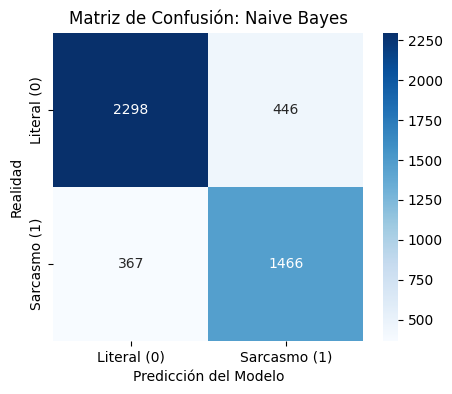


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      2744
           1       0.77      0.80      0.78      1833

    accuracy                           0.82      4577
   macro avg       0.81      0.82      0.82      4577
weighted avg       0.82      0.82      0.82      4577




In [55]:
# CELDA 7: Modelo Naive Bayes

# Modelo simple y muy usado para texto

modelo_nb = MultinomialNB()

# Entrenar modelo
modelo_nb.fit(X_train_vec, y_train)

# Hacer predicciones
y_pred_nb = modelo_nb.predict(X_test_vec)

# Evaluar
evaluar_modelo("Naive Bayes", y_test, y_pred_nb)


==================== SVM ====================

Exactitud (Accuracy): 81.39%


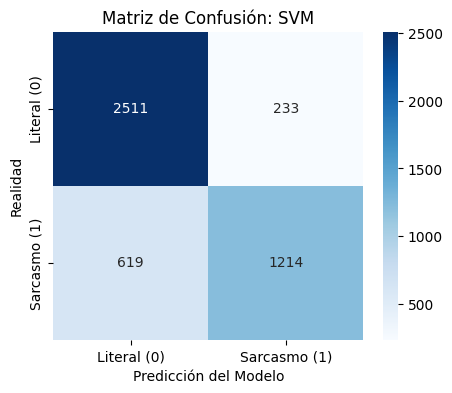


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85      2744
           1       0.84      0.66      0.74      1833

    accuracy                           0.81      4577
   macro avg       0.82      0.79      0.80      4577
weighted avg       0.82      0.81      0.81      4577




In [56]:
# CELDA 8: Modelo SVM
# Modelo más robusto para clasificación

modelo_svm = SVC()

# Entrenar
modelo_svm.fit(X_train_vec, y_train)

# Predecir
y_pred_svm = modelo_svm.predict(X_test_vec)

# Evaluar
evaluar_modelo("SVM", y_test, y_pred_svm)


==================== KNN ====================

Exactitud (Accuracy): 61.04%


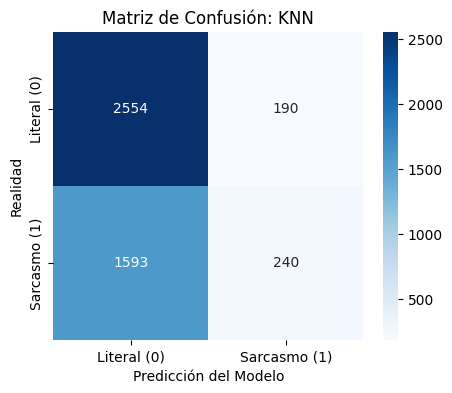


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.62      0.93      0.74      2744
           1       0.56      0.13      0.21      1833

    accuracy                           0.61      4577
   macro avg       0.59      0.53      0.48      4577
weighted avg       0.59      0.61      0.53      4577




In [57]:
# CELDA 9: Modelo KNN
# Clasifica basado en los vecinos más cercanos

modelo_knn = KNeighborsClassifier(n_neighbors=3)

# KNN necesita datos en formato array
modelo_knn.fit(X_train_vec.toarray(), y_train)

# Predicción
y_pred_knn = modelo_knn.predict(X_test_vec.toarray())

# Evaluación
evaluar_modelo("KNN", y_test, y_pred_knn)


==================== Perceptrón Multicapa ====================

Exactitud (Accuracy): 77.63%


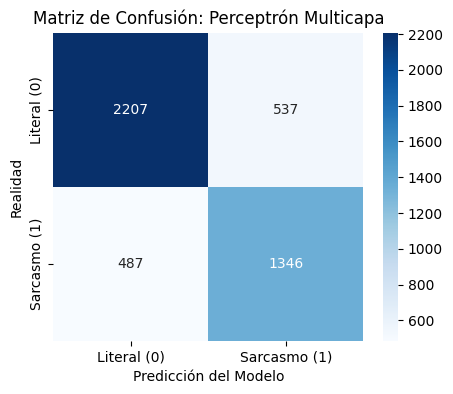


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      2744
           1       0.71      0.73      0.72      1833

    accuracy                           0.78      4577
   macro avg       0.77      0.77      0.77      4577
weighted avg       0.78      0.78      0.78      4577




In [58]:
# CELDA 10: Modelo Perceptron Multicapa Simple

# Modelo más avanzado basado en redes neuronales

modelo_mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500)

# Entrenar
modelo_mlp.fit(X_train_vec, y_train)

# Predecir
y_pred_mlp = modelo_mlp.predict(X_test_vec)

# Evaluar
evaluar_modelo("Perceptrón Multicapa", y_test, y_pred_mlp)
# Transformer HuggingFace
from transformers import pipeline

In [59]:
# CELDA 11: Comparación general de los algoritmos clásicos
print("\n===== RESULTADOS FINALES DE ALGORITMOS CLÁSICOS =====")
resultados = {
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Perceptrón (MLP)": accuracy_score(y_test, y_pred_mlp)
}
for modelo, acc in sorted(resultados.items(), key=lambda x: x[1], reverse=True):
    print(f"{modelo}: {acc*100:.2f}%")



===== RESULTADOS FINALES DE ALGORITMOS CLÁSICOS =====
Naive Bayes: 82.24%
SVM: 81.39%
Perceptrón (MLP): 77.63%
KNN: 61.04%


In [60]:
# CELDA 12: Similitud de Coseno Funcional
# Buscar el comentario de entrenamiento que más se parezca a un comentario de prueba
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Escoge un texto cualquiera
comentario_prueba = "¡Qué maravilla, otra vez sin luz todo el día!"
c_limpio = limpiar_texto(comentario_prueba)
vec_prueba = vectorizer.transform([c_limpio])

# Calculamos la similitud de este comentario contra TODOS los de entrenamiento
similitudes = cosine_similarity(vec_prueba, X_train_vec).flatten()

# Encontrar el índice del más similar
indice_max = np.argmax(similitudes)
comentario_similar = X_train.iloc[indice_max]
sarcasmo_estado = "SÍ " if y_train.iloc[indice_max] == 1 else "NO "

print("COMENTARIO INGRESADO:", comentario_prueba)
print("COMENTARIO MÁS SIMILAR ENCONTRADO:", comentario_similar)
print(f"NIVEL DE SIMILITUD: {similitudes[indice_max]:.4f}")
print(f"¿EL COMENTARIO ENCONTRADO ERA SARCÁSTICO?: {sarcasmo_estado}")


COMENTARIO INGRESADO: ¡Qué maravilla, otra vez sin luz todo el día!
COMENTARIO MÁS SIMILAR ENCONTRADO: pues tal vez algun dia
NIVEL DE SIMILITUD: 0.5164
¿EL COMENTARIO ENCONTRADO ERA SARCÁSTICO?: NO 


Descargando/Cargando pesos de RoBERTuito...



Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7243.18it/s]
RobertaForSequenceClassification LOAD REPORT from: pysentimiento/robertuito-irony
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluando Transformer con 100 muestras:


100%|██████████| 100/100 [00:08<00:00, 12.04it/s]



==================== Transformer (RoBERTuito) ====================

Exactitud (Accuracy): 65.00%


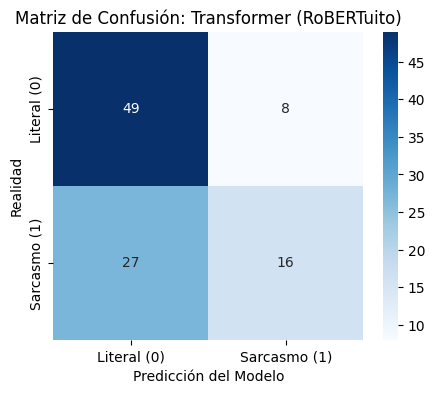


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.64      0.86      0.74        57
           1       0.67      0.37      0.48        43

    accuracy                           0.65       100
   macro avg       0.66      0.62      0.61       100
weighted avg       0.65      0.65      0.63       100




In [61]:
# CELDA 13: Transformer Avanzado (RoBERTuito para Ironía/Sarcasmo en Español)
# NOTA: Este proceso es pesado. Lo probaremos en 100 comentarios al azar del set de prueba.

from transformers import pipeline
from tqdm import tqdm
import random

print("Descargando/Cargando pesos de RoBERTuito...\n")
# Este modelo experto fue entrenado con miles de tweets en español puro
sarcasm_pipeline = pipeline('text-classification', model='pysentimiento/robertuito-irony')

# Extraemos 100 índices de prueba al azar
num_muestras = min(100, len(X_test))
indices_demo = random.sample(range(len(X_test)), num_muestras)

y_true_trf = []
y_pred_trf = []

print(f"Evaluando Transformer con {num_muestras} muestras:")
for i in tqdm(indices_demo):
    # IMPORTANTE: Aquí se pasa el texto original, ¡no la bolsa de palabras!
    txt = df.loc[X_test.index[i], 'comentario'] 
    
    salida = sarcasm_pipeline(txt[:250])
    
    # ¡AQUÍ ESTÁ LA CORRECCIÓN! El modelo devuelve 'ironic' no 'irony'.
    prediccion = 1 if salida[0]['label'] == 'ironic' else 0
    real = y_test.iloc[i]
    
    y_true_trf.append(real)
    y_pred_trf.append(prediccion)

# Evaluamos el poder del Transformer frente a los algoritmos clásicos
evaluar_modelo("Transformer (RoBERTuito)", y_true_trf, y_pred_trf)


In [62]:
# CELDA 14: Exportación de Modelos para la Aplicación Web
import joblib

print("Guardando vectores y modelos de Machine Learning...")
joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(modelo_nb, "modelo_nb.pkl")
joblib.dump(modelo_svm, "modelo_svm.pkl")
joblib.dump(modelo_knn, "modelo_knn.pkl")
joblib.dump(modelo_mlp, "modelo_mlp.pkl")
joblib.dump(X_train_vec, "X_train_vec.pkl")
joblib.dump(y_train, "y_train.pkl")
print("Exportación Lista Archivos .pkl generados con éxito.")


Guardando vectores y modelos de Machine Learning...
Exportación Lista Archivos .pkl generados con éxito.
